In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('../data/FlightDelays/train.csv')

### ✈️ **항공편 데이터 설명**


- **ID**: 샘플 고유 id  

- **Month**: 해당 항공편의 출발 월  

- **Day_of_Month**: Month에 해당하는 월의 날짜  

- **Estimated_Departure_Time**: 전산 시스템을 바탕으로 측정된 비행기의 출발 시간 (현지 시각, HH:MM 형식)  

- **Estimated_Arrival_Time**: 전산 시스템을 바탕으로 측정된 비행기의 도착 시간 (현지 시각, HH:MM 형식)  

- **Cancelled**: 해당 항공편의 취소 여부 (0: 취소되지 않음, 1: 취소됨)  

- **Diverted**: 해당 항공편의 경유 여부 (0: 취소되지 않음, 1: 취소됨)  

- **Origin_Airport**: 해당 항공편 출발 공항의 고유 코드 (IATA 공항 코드)  

- **Origin_Airport_ID**: 해당 항공편 출발 공항의 고유 ID (US DOT ID)  

- **Origin_State**: 해당 항공편 출발 공항이 위치한 주의 이름  

- **Destination_Airport**: 해당 항공편 도착 공항의 고유 코드 (IATA 공항 코드)  

- **Destination_Airport_ID**: 해당 항공편 도착 공항의 고유 ID (US DOT ID)  

- **Destination_State**: 해당 항공편 도착 공항이 위치한 주의 이름  

- **Distance**: 출발 공항과 도착 공항 사이의 거리 (mile 단위)  

- **Airline**: 해당 항공편을 운항하는 항공사  

- **Carrier_Code (IATA)**: 해당 항공편을 운항하는 항공사의 고유 코드  
  (단, 다른 항공사가 같은 코드를 보유할 수도 있음)  

- **Carrier_ID (DOT)**: 해당 항공편을 운항하는 항공사의 고유 ID (US DOT ID)  

- **Tail_Number**: 해당 항공편을 운항하는 항공기의 고유 등록번호  

---

### 🎯 **타깃 변수**

- **Delay**: 항공편 지연 여부 (Not_Delayed, Delayed)  
  - 예측해야 하는 타깃  
  - 다수의 데이터에 레이블이 존재하지 않음  
  - 준지도학습을 통해 레이블링 가능

### 

In [3]:
df

,ID,Month,Day_of_Month,Estimated_Departure_Time,Estimated_Arrival_Time,Cancelled,Diverted,Origin_Airport,Origin_Airport_ID,Origin_State,Destination_Airport,Destination_Airport_ID,Destination_State,Distance,Airline,Carrier_Code(IATA),Carrier_ID(DOT),Tail_Number,Delay
0,TRAIN_000000,4,15,NaN,NaN,0,0,OKC,13851,Oklahoma,HOU,12191,Texas,419.0,Southwest Airlines Co.,WN,19393.0,N7858A,NaN
1,TRAIN_000001,8,15,740.0,1024.0,0,0,ORD,13930,Illinois,SLC,14869,Utah,1250.0,SkyWest Airlines Inc.,UA,20304.0,N125SY,NaN
2,TRAIN_000002,9,6,1610.0,1805.0,0,0,CLT,11057,North Carolina,LGA,12953,New York,544.0,American Airlines Inc.,AA,19805.0,N103US,NaN
3,TRAIN_000003,7,10,905.0,1735.0,0,0,LAX,12892,California,EWR,11618,New Jersey,2454.0,United Air Lines Inc.,UA,NaN,N595UA,NaN
4,TRAIN_000004,1,11,900.0,1019.0,0,0,SFO,14771,California,ACV,10157,California,250.0,SkyWest Airlines Inc.,UA,20304.0,N161SY,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,TRAIN_999995,9,18,936.0,1243.0,0,0,ORD,13930,NaN,PHL,14100,NaN,678.0,United Air Lines Inc.,UA,19977.0,N477UA,NaN
999996,TRAIN_999996,5,30,920.0,1028.0,0,0,FAR,11637,NaN,MSP,13487,Minnesota,223.0,SkyWest Airlines Inc.,DL,NaN,N439SW,NaN
999997,TRAIN_999997,6,28,800.0,1340.0,0,0,OAK,13796,NaN,HOU,12191,Texas,1642.0,Southwest Airlines Co.,WN,19393.0,N230WN,NaN
999998,TRAIN_999998,9,27,1613.0,1824.0,0,0,BNA,10693,Tennessee,ATL,10397,NaN,214.0,Delta Air Lines Inc.,DL,19790.0,N968DL,NaN


In [4]:
# 결측치 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 19 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   ID                        1000000 non-null  object 
 1   Month                     1000000 non-null  int64  
 2   Day_of_Month              1000000 non-null  int64  
 3   Estimated_Departure_Time  890981 non-null   float64
 4   Estimated_Arrival_Time    890960 non-null   float64
 5   Cancelled                 1000000 non-null  int64  
 6   Diverted                  1000000 non-null  int64  
 7   Origin_Airport            1000000 non-null  object 
 8   Origin_Airport_ID         1000000 non-null  int64  
 9   Origin_State              890985 non-null   object 
 10  Destination_Airport       1000000 non-null  object 
 11  Destination_Airport_ID    1000000 non-null  int64  
 12  Destination_State         890921 non-null   object 
 13  Distance                  10

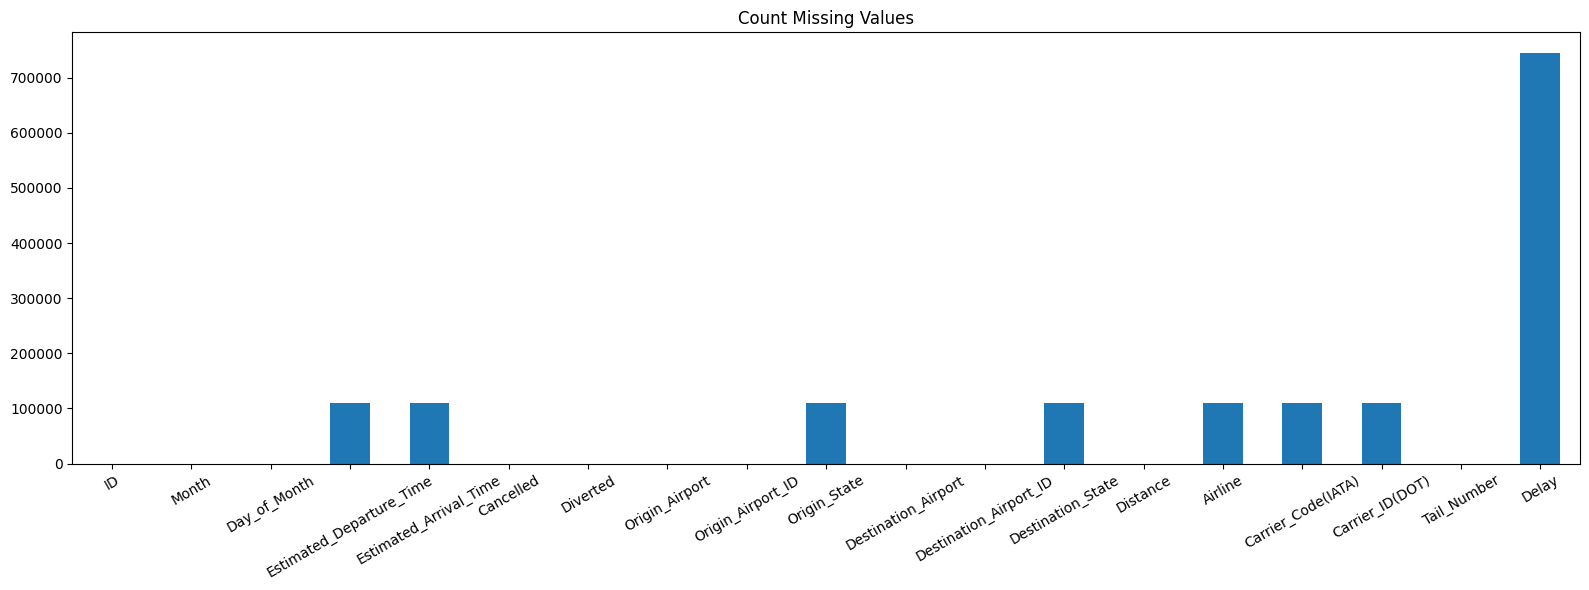

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))

df.isnull().sum().plot(kind='bar')

plt.title('Count Missing Values')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

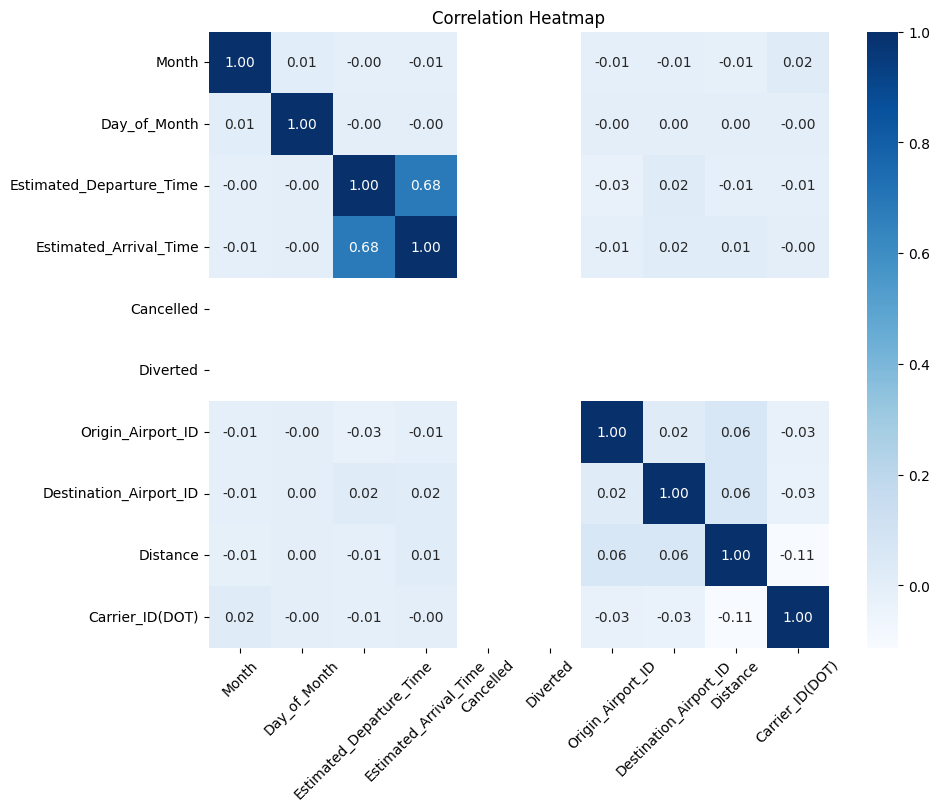

In [6]:
import seaborn as sns

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f')

plt.xticks(rotation=45)
# plt.yticks(rotation=0)

plt.title('Correlation Heatmap')
plt.show()

In [7]:
# Delay가 결측치인 row 삭제
df = df.dropna(subset='Delay')
df

,ID,Month,Day_of_Month,Estimated_Departure_Time,Estimated_Arrival_Time,Cancelled,Diverted,Origin_Airport,Origin_Airport_ID,Origin_State,Destination_Airport,Destination_Airport_ID,Destination_State,Distance,Airline,Carrier_Code(IATA),Carrier_ID(DOT),Tail_Number,Delay
5,TRAIN_000005,4,13,1545.0,NaN,0,0,EWR,11618,NaN,DCA,11278,Virginia,199.0,Republic Airlines,UA,20452.0,N657RW,Not_Delayed
6,TRAIN_000006,1,20,1742.0,1903.0,0,0,EWR,11618,New Jersey,BOS,10721,Massachusetts,200.0,United Air Lines Inc.,UA,NaN,N66825,Not_Delayed
8,TRAIN_000008,6,13,1420.0,1550.0,0,0,BWI,10821,NaN,CLT,11057,North Carolina,361.0,Southwest Airlines Co.,WN,19393.0,N765SW,Not_Delayed
10,TRAIN_000010,8,13,1730.0,1844.0,0,0,DCA,11278,Virginia,PIT,14122,Pennsylvania,204.0,Republic Airlines,AA,NaN,N119HQ,Delayed
12,TRAIN_000012,1,12,1015.0,1145.0,0,0,CLE,11042,Ohio,DEN,11292,Colorado,1201.0,Southwest Airlines Co.,WN,NaN,N8696E,Not_Delayed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999962,TRAIN_999962,10,11,NaN,2003.0,0,0,SAT,14683,Texas,ORD,13930,Illinois,1041.0,SkyWest Airlines Inc.,UA,20304.0,N152SY,Not_Delayed
999963,TRAIN_999963,5,2,1759.0,1926.0,0,0,LGA,12953,New York,DCA,11278,Virginia,214.0,NaN,DL,20452.0,N871RW,Delayed
999969,TRAIN_999969,10,10,940.0,1056.0,0,0,MFE,13256,Texas,IAH,12266,Texas,316.0,Mesa Airlines Inc.,NaN,20378.0,N89321,Delayed
999985,TRAIN_999985,8,8,1914.0,2039.0,0,0,RDU,14492,North Carolina,JAX,12451,Florida,407.0,Frontier Airlines Inc.,F9,20436.0,N316FR,Not_Delayed


# State

In [ ]:
state = df[['Origin_State', 'Destination_State']]

In [ ]:
# Destination_State 결측치 채우기
for i in df['Origin_State'].dropna().unique():
    dest = state.loc[df['Origin_State']==i].mode()['Destination_State'][0]
    state['Destination_State'] = np.where((state['Origin_State']==i) & state['Destination_State'].isna(), dest, state['Destination_State'])

In [ ]:
# Origin_State 결측치 채우기
for i in df['Destination_State'].dropna().unique():
    dest = state.loc[df['Destination_State']==i].mode()['Origin_State'][0]
    state['Origin_State'] = np.where((state['Destination_State']==i) & state['Origin_State'].isna(), dest, state['Origin_State'])

In [ ]:
df['Origin_State'], df['Destination_State'] = state['Origin_State'], state['Destination_State']

## Airline

In [ ]:
df = df.dropna(subset='Origin_State')

In [ ]:
airline = df[['Origin_State', 'Destination_State', 'Airline']]

In [ ]:
for i in df['Origin_State'].unique():
    for j in df.loc[df['Origin_State']==i]['Destination_State'].unique():
        air = airline.loc[(airline['Origin_State']==i)&(airline['Destination_State']==j)].mode()['Airline'][0]
        airline['Airline'] = np.where((airline['Origin_State']==i) & (airline['Destination_State']==j) & airline['Airline'].isna(), air, airline['Airline'])

In [ ]:
df['Airline'] = airline['Airline']

In [ ]:
df.to_csv('Airline.csv',index=False)